<a href="https://colab.research.google.com/github/jnardosp/mcmc_approximate_count/blob/main/Tarea_2_Fran_Tuli_Jsotop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea 2 Cadenas de Markov**
## *Conteo aproximado con MCMC aplicado a los modelos Hard-Core y q-coloraciones*

---

**Profesor:** Freddy Hernández-Romero

**Integrantes del grupo:**
- Juan Bernardo Soto Pescador
- Francisco José Gutiérrez Peña
- Tuli Peña Melo


In [ ]:
# CALCULAR LAS COTAS DE CANTIDAD DE SIMULACIONES Y CANTIDAD DE PASOS

# Computes formulas for K in 3..20, q in 2..15, eps in [0.4,0.6,0.8]
# and saves results to CSV in a safe output directory.
import math
import os
import pandas as pd

Ks = [3,7,11,15,20]
qs = [3, 6, 9, 12, 15]
epsilons = [0.4]

d = 4  # maximum degree for the KxK grid (interior vertices have degree 4)

rows = []
for K in Ks:
    k_vertices = K * K  # k in the formulas (number of vertices)
    tilde_k = 2 * K * (K - 1)  # exact number of edges in KxK grid: 2*K*(K-1)
    for q in qs:
        denom = math.log(q / (q - 1))
        for eps in epsilons:
            max_simulations = 48 * (d ** 2) * (k_vertices ** 3) / (eps ** 2)
            max_gibbs_steps_per_sim = (k_vertices * (2 * math.log(k_vertices) + math.log(1 / eps) + math.log(8)) / denom) + 1.0
            total_max_steps = (d * k_vertices) * max_simulations * max_gibbs_steps_per_sim

            row = {
                "K": K,
                "q": q,
                "epsilon": eps,
                "k_vertices": f"{k_vertices:.0e}",
                "tilde_k_edges": f"{tilde_k:.0e}",
                "d": f"{d:.0e}",
                "max_simulations_per_factor": f"{max_simulations:.6e}",
                "max_gibbs_steps_per_simulation": f"{max_gibbs_steps_per_sim:.6e}",
                "total_max_steps": f"{total_max_steps:.6e}"
            }
            rows.append(row)

df = pd.DataFrame(rows)

# Ensure output directory exists and save CSV
out_dir = "/markov_tarea2"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "tabla_cotas_cantidad_de_pasos.csv")
df.to_csv(out_path, index=False)

# Display first few rows to the user (if environment supports the display helper)
try:
    import caas_jupyter_tools as tools
    tools.display_dataframe_to_user("ApproxCountingSample_Fixed", df.head(20))
except Exception:
    # fallback: print head
    print(df.head(10).to_string(index=False))

out_path

In [ ]:
# CORRER SIMULACIONES

# approx_count_grid_savecsv.py
# -*- coding: utf-8 -*-
"""
Aproximación del número de q-coloraciones en rejillas KxK
Guarda un resumen CSV en /markov_tarea2/q_coloraciones_summary.csv
Imprime por consola cada línea que va a escribir en el CSV.
"""

import random
import math
import time
import os
import csv

# Parámetros fijos pedidos
K_list = [3, 5, 7]
q_list = [3, 6, 9, 12, 15]
eps_list = [0.4, 0.6, 0.8]

NUM_SIMULATIONS = 300  # fijo

random.seed(2025)  # reproducibilidad; quita o cambia si deseas

# Ruta de salida CSV
OUT_DIR = "/markov_tarea2"
OUT_CSV = os.path.join(OUT_DIR, "q_coloraciones_summary.csv")

# Construir lista de aristas para una rejilla KxK (nodos indexados 0..n-1)
def build_grid_edges(K):
    edges = []
    def vid(i, j): return i * K + j
    for i in range(K):
        for j in range(K):
            if i + 1 < K:
                edges.append((vid(i, j), vid(i + 1, j)))
            if j + 1 < K:
                edges.append((vid(i, j), vid(i, j + 1)))
    return edges

# Paridad (bipartición) de cada vértice en la rejilla: (i+j) % 2
def build_parity(K):
    parity = []
    for i in range(K):
        for j in range(K):
            parity.append((i + j) % 2)
    return parity

# Crea un coloring inicial propio para cualquier subgrafo de la rejilla,
# usando la bipartición (parity) y mapeando cada parte a un color distinto elegido aleatoriamente.
def initial_proper_coloring_from_parity(q, parity):
    n = len(parity)
    if q >= 2:
        c0, c1 = random.sample(range(q), 2)
    else:
        c0 = 0
        c1 = 0
    coloring = [None] * n
    for v in range(n):
        coloring[v] = c0 if parity[v] == 0 else c1
    return coloring

# Ejecuta el Gibbs sampler sobre el espacio de coloraciones propias del grafo definido por adjacency (lista de sets)
def run_gibbs_sampler(coloring, adjacency, q, n_steps):
    n = len(coloring)
    state = coloring[:]
    for _ in range(n_steps):
        v = random.randrange(n)
        forbidden = set(state[u] for u in adjacency[v])
        allowed = [c for c in range(q) if c not in forbidden]
        # seguridad: si allowed vacío (no debe ocurrir en grafos bipartitos con q>=2), elegir color actual
        if not allowed:
            continue
        state[v] = random.choice(allowed)
    return state

# Estima p_j = Pr_{colorings of G_{j-1}}(X(u) != X(v)) mediante NUM_SIMULATIONS independientes.
def estimate_edge_ratio(adjacency_current, u, v, q, n_steps_gibbs, parity):
    successes = 0
    n_vertices = len(adjacency_current)
    for sim in range(NUM_SIMULATIONS):
        init_col = initial_proper_coloring_from_parity(q, parity)
        sample = run_gibbs_sampler(init_col, adjacency_current, q, n_steps_gibbs)
        if sample[u] != sample[v]:
            successes += 1
    return successes / float(NUM_SIMULATIONS)

# Cálculo del número de pasos del Gibbs sampler usando la fórmula dada:
def compute_gibbs_steps(k_vertices, q, eps):
    if q <= 1:
        raise ValueError("q debe ser > 1 para la fórmula del denominador.")
    denom = math.log(q / (q - 1))
    numerator = k_vertices * (2 * math.log(k_vertices) + math.log(1.0 / eps) + math.log(8.0))
    val = (numerator / denom) + 1.0
    return int(math.ceil(val))

# Ejecuta el procedimiento para un K, q, eps concreto y devuelve la estimación
def approximate_count_for(K, q, eps, verbose=False):
    n_vertices = K * K
    edges = build_grid_edges(K)
    parity = build_parity(K)
    adjacency_current = [set() for _ in range(n_vertices)]
    product = 1.0

    n_steps_gibbs = compute_gibbs_steps(n_vertices, q, eps)
    if verbose:
        print(f"  K={K} n_vertices={n_vertices}, q={q}, eps={eps}")
        print(f"  pasos Gibbs por simulación = {n_steps_gibbs}, simulaciones por factor = {NUM_SIMULATIONS}")
        print(f"  número de aristas (factores) = {len(edges)}")

    for j, (u, v) in enumerate(edges, start=1):
        p_hat = estimate_edge_ratio(adjacency_current, u, v, q, n_steps_gibbs, parity)
        product *= p_hat
        adjacency_current[u].add(v)
        adjacency_current[v].add(u)
        if verbose and (j % max(1, len(edges)//10) == 0):
            print(f"    factor {j}/{len(edges)} p_hat={p_hat:.4g}  (producto parcial={product:.4g})")

    Z0 = (q ** n_vertices)
    Z_est = Z0 * product
    return {
        "K": K,
        "q": q,
        "eps": eps,
        "n_vertices": n_vertices,
        "num_edges": len(edges),
        "gibbs_steps_per_sim": n_steps_gibbs,
        "simulations_per_factor": NUM_SIMULATIONS,
        "Z0": Z0,
        "estimate": Z_est,
        "product_of_ratios": product
    }

# Asegura que el directorio de salida exista y prepara el CSV (escribe cabecera)
def prepare_csv(out_dir, out_csv):
    os.makedirs(out_dir, exist_ok=True)
    header = [
        "K", "q", "eps", "n_vertices", "num_edges",
        "gibbs_steps_per_sim", "simulations_per_factor",
        "Z0", "estimate", "product_of_ratios", "time_seconds"
    ]
    # abrir y escribir cabecera (sobrescribe si existe)
    with open(out_csv, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(header)
    print(f"CSV preparado en: {out_csv} (cabecera escrita)")

# Escribe una fila en el CSV (apend)
def append_row_csv(out_csv, row):
    # construir línea CSV como cadena para imprimir
    # usamos csv module para asegurar formato correcto al escribir
    with open(out_csv, mode="a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(row)

def main():
    prepare_csv(OUT_DIR, OUT_CSV)
    results = []
    total_start = time.time()
    for K in K_list:
        for q in q_list:
            for eps in eps_list:
                start = time.time()
                print(f"\nEjecutando K={K}, q={q}, eps={eps} ...")
                res = approximate_count_for(K, q, eps, verbose=True)
                dur = time.time() - start
                res["time_seconds"] = dur
                results.append(res)

                # Preparar fila y mostrarla por consola ANTES de escribir
                row = [
                    res["K"],
                    res["q"],
                    res["eps"],
                    res["n_vertices"],
                    res["num_edges"],
                    res["gibbs_steps_per_sim"],
                    res["simulations_per_factor"],
                    "{:.0f}".format(res["Z0"]),                       # Z0 entero grande
                    "{:.12e}".format(res["estimate"]),                # estimate en notación científica
                    "{:.12e}".format(res["product_of_ratios"]),      # producto de razones
                    "{:.4f}".format(res["time_seconds"])
                ]
                # imprimir la línea CSV que vamos a escribir
                print("Escribiendo CSV -> " + ",".join(map(str, row)))
                # escribir la fila
                append_row_csv(OUT_CSV, row)

                print(f" -> Resultado guardado. estimate={res['estimate']:.6g}, tiempo={dur:.1f}s")
    total_time = time.time() - total_start
    print(f"\nTodos los experimentos completados en {total_time:.1f} segundos (tiempo total en esta ejecución).")
    print(f"Resumen guardado en: {OUT_CSV}")
    return results

if __name__ == "__main__":
    main()

In [ ]:
# CONTEO EXACTO

#!/usr/bin/env python3
import os
import csv
import time
from itertools import product

def generate_row_states(K, q):
    """Genera todas las filas (tuplas) de longitud K con q colores
    donde no hay dos colores iguales consecutivos en la fila."""
    if K == 0:
        return [()]
    states = []
    def backtrack(prefix):
        if len(prefix) == K:
            states.append(tuple(prefix))
            return
        for color in range(q):
            if not prefix or prefix[-1] != color:
                prefix.append(color)
                backtrack(prefix)
                prefix.pop()
    backtrack([])
    return states

def count_grid_colorings(K, q):
    """Cuenta coloraciones de una grilla K x K (restricción: no igual adyacente horizontal ni vertical)
    usando estados por fila y recuento por transferencia."""
    if q < 1:
        return 0
    states = generate_row_states(K, q)
    nstates = len(states)
    # compatibilidad: para cada estado i, lista de estados j que son compatibles (ninguna columna con el mismo color)
    compat = [[] for _ in range(nstates)]
    for i, a in enumerate(states):
        for j, b in enumerate(states):
            ok = True
            for x, y in zip(a, b):
                if x == y:
                    ok = False
                    break
            if ok:
                compat[i].append(j)
    # vector de conteos por estado (inicialmente 1 para la primera fila)
    counts = [1] * nstates
    # multiplicar por K-1 veces (número de transiciones de fila)
    for _ in range(1, K):
        new_counts = [0] * nstates
        for i in range(nstates):
            ci = counts[i]
            if ci == 0:
                continue
            for j in compat[i]:
                new_counts[j] += ci
        counts = new_counts
    return sum(counts)

def estimated_num_states(K, q):
    """Estimación rápida del número de estados (sin generarlos): q * (q-1)^(K-1) para K>=1"""
    if K == 0:
        return 1
    return q * ((q - 1) ** (K - 1))

if __name__ == "__main__":
    K_list = [3, 5]
    q_list = [3, 6, 9, 12, 15]

    out_path = "/markov_tarea2/conteo_exacto.csv"
    # Si True, saltará las combinaciones cuyo número estimado de estados exceda THRESHOLD_STATES
    SKIP_LARGE = True
    THRESHOLD_STATES = 3_000_000  # ajustar según memoria/tiempo disponible

    # Crear carpeta si hace falta
    out_dir = os.path.dirname(out_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # Abrir CSV y escribir encabezado
    with open(out_path, mode="w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["K", "q", "estimated_states", "result", "elapsed_seconds", "status"])

        # Iterar combinaciones
        for K in K_list:
            for q in q_list:
                est = estimated_num_states(K, q)
                print("-" * 60)
                print(f"Preparando cálculo: K={K}, q={q}")
                print(f"Estimación de número de estados: {est:,}")
                # Decidir si se salta
                if SKIP_LARGE and est > THRESHOLD_STATES:
                    status = f"SKIPPED (estimated states {est:,} > threshold {THRESHOLD_STATES:,})"
                    print("AVISO: se omite esta combinación por exceso de estados (riesgo de memoria/CPU).")
                    print(f"Escribiendo en CSV: status = {status}")
                    writer.writerow([K, q, est, "", "", status])
                    # flush para asegurar escritura inmediata
                    csvfile.flush()
                    continue

                # Ejecutar cálculo y medir tiempo
                t0 = time.time()
                try:
                    result = count_grid_colorings(K, q)
                    elapsed = time.time() - t0
                    status = "OK"
                    print(f"Resultado: numero de coloraciones para grilla {K}x{K} con {q} colores = {result}")
                    print(f"Tiempo tomado: {elapsed:.3f} s")
                    # Escribir fila en CSV
                    writer.writerow([K, q, est, result, f"{elapsed:.6f}", status])
                    csvfile.flush()
                except MemoryError:
                    elapsed = time.time() - t0
                    status = "FAILED_MEMORY"
                    print("ERROR: se quedó sin memoria durante el cálculo.")
                    writer.writerow([K, q, est, "", f"{elapsed:.6f}", status])
                    csvfile.flush()
                except Exception as e:
                    elapsed = time.time() - t0
                    status = f"FAILED_EXCEPTION: {e}"
                    print(f"ERROR: excepción durante el cálculo: {e}")
                    writer.writerow([K, q, est, "", f"{elapsed:.6f}", status])
                    csvfile.flush()

    print("-" * 60)
    print(f"Proceso terminado. Resultados guardados en: {out_path}")

Columnas detectadas:
Exacto: K q result
Aproximado: K q eps estimate
Ks: [3, 5, 7]


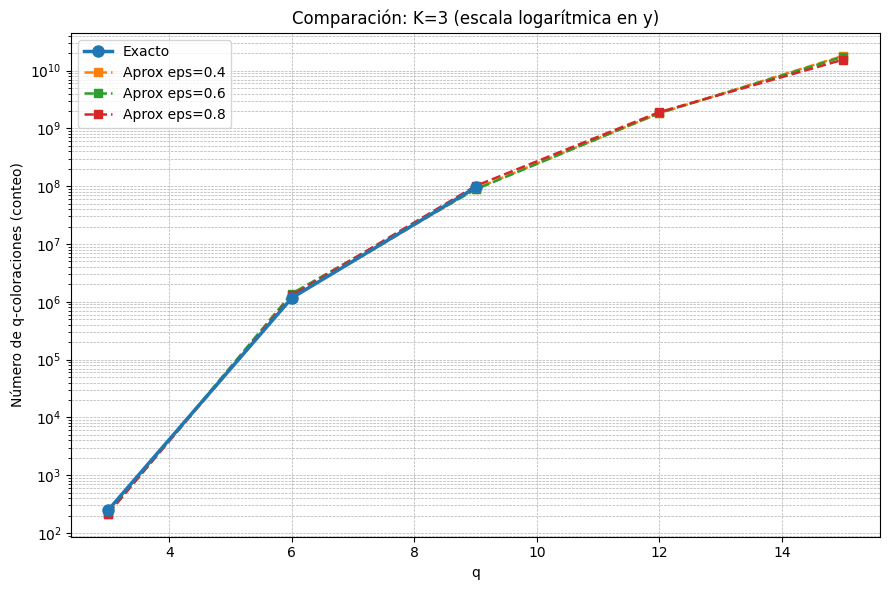

Guardado: plot_K_3.png  (log scale: True)


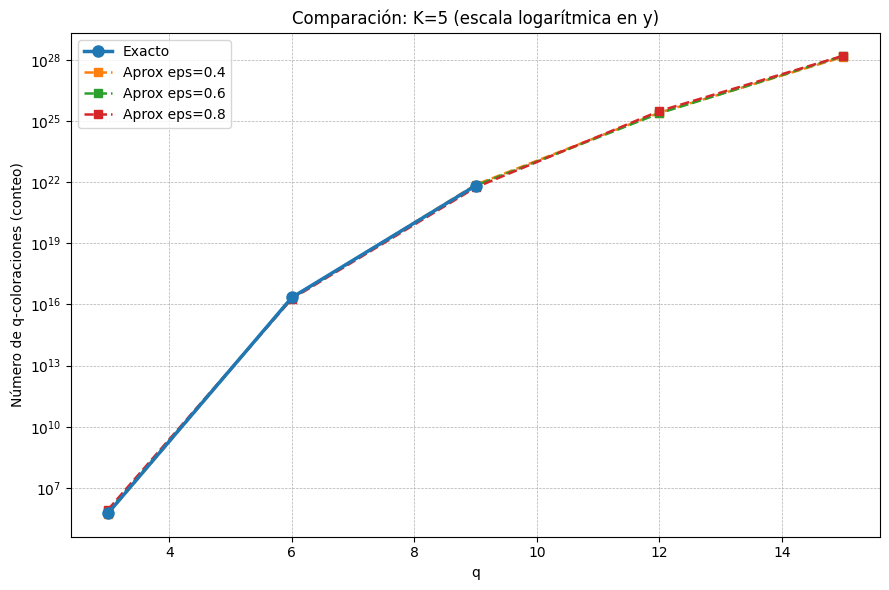

Guardado: plot_K_5.png  (log scale: True)


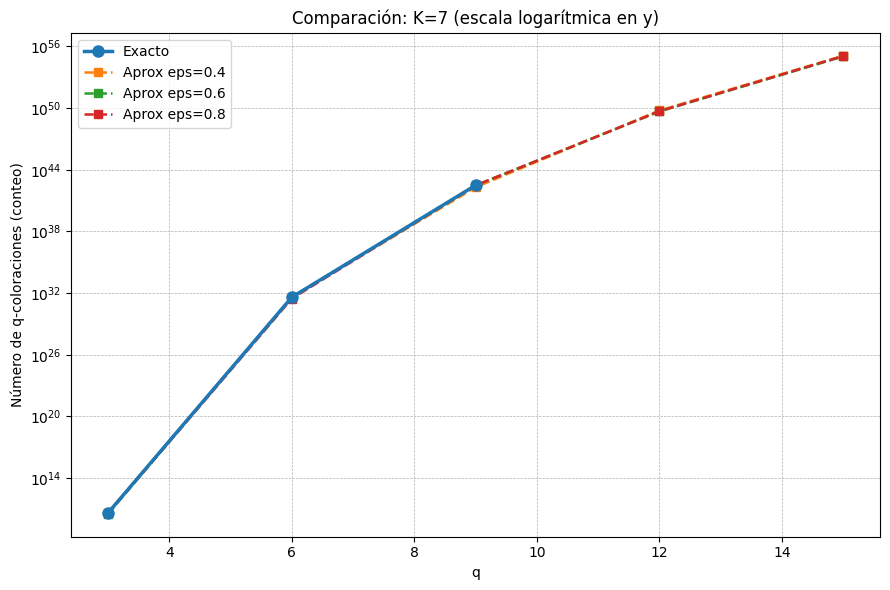

Guardado: plot_K_7.png  (log scale: True)

Generados:
plot_K_3.png
plot_K_5.png
plot_K_7.png


In [ ]:
# GRÁFICAS COMPARACIÓN CONTEO EXACTO VS CONTEO APROXIMADO

import os
import pandas as pd
import matplotlib.pyplot as plt
from math import isfinite

exact_path = "conteo_exacto.csv"
approx_path = "conteo_aproximado.csv"

def find_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None

# Cargar
exact_df = pd.read_csv(exact_path)
approx_df = pd.read_csv(approx_path)

# Detectar columnas
K_col_exact = find_col(exact_df, ["K", "k"])
q_col_exact = find_col(exact_df, ["q", "Q"])
count_col_exact = find_col(exact_df, ["count", "conteo", "result", "valor", "exact"])
if count_col_exact is None:
    numeric_cols = exact_df.select_dtypes(include='number').columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in ([K_col_exact, q_col_exact] if K_col_exact and q_col_exact else [])]
    count_col_exact = numeric_cols[0] if numeric_cols else None

K_col_approx = find_col(approx_df, ["K", "k"])
q_col_approx = find_col(approx_df, ["q", "Q"])
eps_col_approx = find_col(approx_df, ["eps", "epsilon", "epsilons"])
count_col_approx = find_col(approx_df, ["estimate", "est", "approx", "value", "valor", "conteo", "result"])
if count_col_approx is None:
    numeric_cols = approx_df.select_dtypes(include='number').columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in ([K_col_approx, q_col_approx, eps_col_approx] if K_col_approx and q_col_approx and eps_col_approx else [])]
    count_col_approx = numeric_cols[0] if numeric_cols else None

# Fallbacks simples
if K_col_exact is None and "K" in exact_df.columns: K_col_exact = "K"
if q_col_exact is None and "q" in exact_df.columns: q_col_exact = "q"
if K_col_approx is None and "K" in approx_df.columns: K_col_approx = "K"
if q_col_approx is None and "q" in approx_df.columns: q_col_approx = "q"

# Convertir a numérico
for df, cols in [(exact_df, [K_col_exact, q_col_exact, count_col_exact]), (approx_df, [K_col_approx, q_col_approx, eps_col_approx, count_col_approx])]:
    for c in cols:
        if c and c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

# Ks disponibles
Ks = sorted(set(exact_df[K_col_exact].dropna().unique().tolist() + approx_df[K_col_approx].dropna().unique().tolist()))

print("Columnas detectadas:")
print("Exacto:", K_col_exact, q_col_exact, count_col_exact)
print("Aproximado:", K_col_approx, q_col_approx, eps_col_approx, count_col_approx)
print("Ks:", Ks)

output_images = []

for K in Ks:
    exact_k = exact_df[exact_df[K_col_exact] == K].copy()
    approx_k = approx_df[approx_df[K_col_approx] == K].copy()
    if exact_k.empty and approx_k.empty:
        continue

    # Agrupar por q y tomar media si hay duplicados
    exact_agg = None
    if not exact_k.empty and count_col_exact in exact_k.columns:
        exact_agg = exact_k.groupby(q_col_exact)[count_col_exact].mean().sort_index()

    approx_agg_by_eps = {}
    if not approx_k.empty and count_col_approx in approx_k.columns:
        if eps_col_approx in approx_k.columns:
            for eps in sorted(approx_k[eps_col_approx].dropna().unique()):
                sub = approx_k[approx_k[eps_col_approx] == eps]
                approx_agg_by_eps[eps] = sub.groupby(q_col_approx)[count_col_approx].mean().sort_index()
        else:
            approx_agg_by_eps["approx"] = approx_k.groupby(q_col_approx)[count_col_approx].mean().sort_index()

    # Reunir todos los valores numéricos para decidir escala
    all_values = []
    if exact_agg is not None:
        all_values += [v for v in exact_agg.values if isfinite(v) and v>0]
    for v in approx_agg_by_eps.values():
        all_values += [x for x in v.values if isfinite(x) and x>0]

    use_log = False
    if len(all_values) >= 2:
        maxv = max(all_values)
        minv = min(all_values)
        ratio = maxv / minv if minv>0 else float('inf')
        # Umbral: si la relación es muy grande, usar escala log
        if ratio > 1000:
            use_log = True

    plt.figure(figsize=(9,6))
    plt.title(f"Comparación: K={K}")
    plt.xlabel("q")
    plt.ylabel("Número de q-coloraciones (conteo)")

    # Plot exact (resaltar)
    if exact_agg is not None and not exact_agg.empty:
        # plot with bold line and larger markers so it is visible even in linear scale
        plt.plot(exact_agg.index.values, exact_agg.values, marker='o', linewidth=2.5, markersize=8, label="Exacto", zorder=5)

    # Plot approximate by eps
    for eps, series in approx_agg_by_eps.items():
        if series is None or series.empty:
            continue
        # use dashed line and square markers; keep linewidth slightly thinner
        label = f"Aprox eps={eps}" if eps != "approx" else "Aprox"
        plt.plot(series.index.values, series.values, marker='s', linestyle='--', linewidth=1.8, markersize=6, label=label, zorder=4)

    if use_log:
        # Remove zeros or negatives before setting log scale to avoid errors
        plt.yscale('log')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.title(f"Comparación: K={K} (escala logarítmica en y)")
    else:
        plt.grid(True)
    plt.legend()
    plt.tight_layout()

    out_path = f"plot_K_{int(K)}.png" if float(K).is_integer() else f"plot_K_{K}.png"
    plt.savefig(out_path)
    plt.show()
    print(f"Guardado: {out_path}  (log scale: {use_log})")
    output_images.append(out_path)

print("\nGenerados:")
for p in output_images:
    print(p)

In [ ]:
# Código que genera un CSV con: K, q, valor_exacto, valor_aproximado_eps0.4, diferencia (aprox - exact)
import pandas as pd
from math import isfinite

exact_path = "conteo_exacto.csv"
approx_path = "conteo_aproximado.csv"
out_path = "comparacion_eps0.4.csv"

def find_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None

# Cargar archivos
exact_df = pd.read_csv(exact_path)
approx_df = pd.read_csv(approx_path)

# Detectar columnas
K_col_exact = find_col(exact_df, ["K", "k"])
q_col_exact = find_col(exact_df, ["q", "Q"])
count_col_exact = find_col(exact_df, ["count", "conteo", "result", "valor", "exact"])
if count_col_exact is None:
    # fallback to first numeric that's not K/q
    numeric = exact_df.select_dtypes(include='number').columns.tolist()
    numeric = [c for c in numeric if c not in ([K_col_exact, q_col_exact] if K_col_exact and q_col_exact else [])]
    count_col_exact = numeric[0] if numeric else exact_df.columns[-1]

K_col_approx = find_col(approx_df, ["K", "k"])
q_col_approx = find_col(approx_df, ["q", "Q"])
eps_col_approx = find_col(approx_df, ["eps", "epsilon", "epsilons"])
count_col_approx = find_col(approx_df, ["estimate", "est", "approx", "value", "valor", "conteo", "result"])
if count_col_approx is None:
    numeric = approx_df.select_dtypes(include='number').columns.tolist()
    numeric = [c for c in numeric if c not in ([K_col_approx, q_col_approx, eps_col_approx] if K_col_approx and q_col_approx and eps_col_approx else [])]
    count_col_approx = numeric[0] if numeric else approx_df.columns[-1]

# Convertir a numérico
for df, cols in [(exact_df, [K_col_exact, q_col_exact, count_col_exact]), (approx_df, [K_col_approx, q_col_approx, eps_col_approx, count_col_approx])]:
    for c in cols:
        if c and c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

# Filtrar aproximados con eps = 0.4
eps_value = 0.4
if eps_col_approx not in approx_df.columns:
    raise ValueError(f"No se encontró columna de epsilon en {approx_path}. Column candidates checked earlier.")
approx_eps = approx_df[approx_df[eps_col_approx] == eps_value].copy()

# Agregar por K,q (media si hay duplicados)
exact_agg = exact_df.groupby([K_col_exact, q_col_exact])[count_col_exact].mean().reset_index().rename(columns={count_col_exact: "valor_exacto"})
approx_agg = approx_eps.groupby([K_col_approx, q_col_approx])[count_col_approx].mean().reset_index().rename(columns={count_col_approx: f"valor_aprox_eps{eps_value}"})

# Unir (inner join para conservar solo combinaciones con ambos valores)
merged = pd.merge(exact_agg, approx_agg, left_on=[K_col_exact, q_col_exact], right_on=[K_col_approx, q_col_approx], how="inner")

# Normalizar nombres de columnas K,q
merged = merged.rename(columns={K_col_exact: "K", q_col_exact: "q"})
# Calcular diferencia (aprox - exacto)
merged["diferencia"] = merged[f"valor_aprox_eps{eps_value}"] - merged["valor_exacto"]
# Opcional: diferencia absoluta y relativa
merged["diferencia_abs"] = merged["diferencia"].abs()
merged["diferencia_relativa"] = merged["diferencia"] / merged["valor_exacto"].replace({0: pd.NA})

# Reordenar columnas
cols_order = ["K", "q", "valor_exacto", f"valor_aprox_eps{eps_value}", "diferencia", "diferencia_abs", "diferencia_relativa"]
merged = merged[cols_order]

# Guardar CSV
merged.to_csv(out_path, index=False)

print("CSV guardado en:", out_path)

CSV guardado en: comparacion_eps0.4.csv
